In [37]:
import numpy as np
import random
from random import randint
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [86]:
def weighted_median_general(data, weights):
    # Pair each data point with its weight and sort by data point
    data_weights = sorted(zip(data, weights))
    
    total_weight = sum(weights)
    cumulative_weight = 0.0
    
    for value, weight in data_weights:
        cumulative_weight += weight
        if cumulative_weight >= total_weight / 2.0:
            return value
    
    # If for some reason the loop completes without returning, return the last value
    return data[-1]
def weighted_median(data, weights):
    max_n = 1005
    m = len(data)
    cc = [0.0]*(max_n+1)
    for i in range(m):
        if data[i]>max_n:
            cc[max_n] += weights[i]
        else:
            cc[data[i]] += weights[i]
    w = 0
    tot_weight = sum(cc) * 0.5
    for i in range(max_n+1):
        w += cc[i]
        if w>tot_weight:
            return i
def plot_series(arr):
    plt.plot(arr)
    plt.show()
def plot_dist(arr):
    plt.hist(arr, bins=np.arange(min(arr), max(arr)+1), edgecolor='black')
    plt.show()
fac_max = 155
fac=[1]
for i in range(1,fac_max):
    fac.append(fac[-1]*i)
ffac = np.array(fac).astype(float)
binom_mat = np.zeros((fac_max,fac_max))
for i in range(fac_max):
    for j in range(fac_max):
        binom_mat[i,j] = fac[i]/(fac[j]*fac[i-j])
def get_fac(n):
    #return fac[n]
    return ffac[n]
def binom(n,m):
    #return (fac[n])//(fac[m]*fac[n-m])
    #return get_fac(n)/(get_fac(m)*get_fac(n-m))
    return binom_mat[n,m]
def find_list_median(numbers):
    sorted_numbers = sorted(numbers)
    n = len(sorted_numbers)
    mid = n // 2
    return (sorted_numbers[mid] + sorted_numbers[~mid]) / 2
def apply_bounds(value, lower_bound, upper_bound):
    return max(lower_bound, min(value, upper_bound))
def get_game_value():
    di=100
    while di>10 or bo>12 or bo<2:
        t1=randint(2,22)
        t2=randint(2,int( (100-t1)/4 + 2 )  )
        t3=randint(1,int( (100-t1-t2)/3 + 1 )  )
        t4=randint(0,int( (100-t1-t2-t3)/2  )  )
        t5=randint(0,int( (100-t1-t2-t3-t4)  )  )
        di,bo,g,s,br = sorted([t1,t2,t3,t4,t5])
    return ([br,s,g,bo,di])
def get_yield_by_picked(picked):
    return ( (picked[0]*2+picked[1]*5+picked[2]*10)*(2**picked[4]) )  
def sample_picked_once(game_value):
    left = game_value.copy()
    picked = [0]*5
    while(sum(left)>=1 and picked[3]<2):
        now = random.choices(list(range(5)), left, k=1)[0]
        left[now] -= 1
        picked[now] += 1
    return picked
def sample_yield_once(game_value):
    picked = sample_picked_once(game_value)
    return get_yield_by_picked(picked)
def sample_median(game_value):
    lst = []
    for i in range(1000000):
        lst.append( sample_yield_once(game_value) )
    return find_list_median(lst)
def count_realization(type_value,game_value):
    type_sum = sum(type_value)
    uni_sum = sum(game_value)
    res = 1.0
    for i in range(5):
        res=res*binom(game_value[i],type_value[i])
    res=res/binom(uni_sum,type_sum)
    res=res*2.0/type_sum
    return res
def get_ywlst(game_value):
    # lack  * 2.0 * binom(game_value[3],2)
    res = []
    uni_sum = sum(game_value)
    type_sum = 2
    y = 0
    for br in range(game_value[0]+1):
        y = y + br*2
        type_sum = type_sum + br
        wbr = binom(game_value[0],br)
        for s in range(game_value[1]+1):
            y = y + s*5
            type_sum = type_sum + s
            ws = wbr * binom(game_value[1],s)
            for g in range(game_value[2]+1):
                y = y + g*10
                type_sum = type_sum + g
                wg = ws * binom(game_value[2],g)
                yy = y
                for di in range(game_value[4]+1):
                    type_sum = type_sum + di
                    now = [br,s,g,2,di]
                    w =  wg * binom(game_value[4],di) / ( binom(uni_sum,type_sum)*type_sum )
                    res.append((yy,w))
                    yy = yy*2
                    type_sum = type_sum - di
                y = y - g*10
                type_sum = type_sum -g
            y = y - s*5
            type_sum = type_sum - s
        y = y - br*2
        type_sum = type_sum - br
    return res
def get_ywlst_oldversion(game_value):
    res = []
    for br in range(game_value[0]+1):
        for s in range(game_value[1]+1):
            for g in range(game_value[2]+1):
                for di in range(game_value[4]+1):
                    now = [br,s,g,2,di]
                    w = count_realization(now,game_value)
                    y = get_yield_by_picked(now)
                    res.append((y,w))
    return res
def get_median_by_ywlst(game_value):
    ywlst = get_ywlst(game_value)
    #sorted_ywlist = sorted(ywlst)
    list_of_tuple = tuple(map(list, zip(*ywlst)))
    ylst = list_of_tuple[0]
    wlst = list_of_tuple[1]
    return weighted_median(ylst,wlst)

In [5]:
#lst = [1,2,1,3,1]
#print(  get_ywlst(lst)  )
#print(  get_ywlst_oldversion(lst)  )

In [6]:
lst = [31,41,31,13,31]

In [11]:
x = get_ywlst(lst)

In [8]:
x = get_ywlst_oldversion(lst)

In [17]:
get_median_by_ywlst([11,11,10,9,8])

74

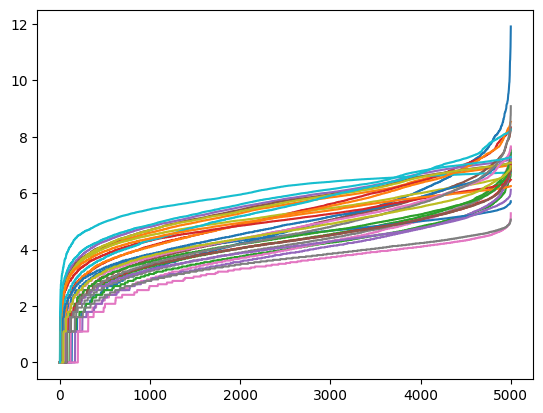

[]
[]


In [89]:
game_value = get_game_value()
arr = []
medlst = []
for i in range(30):
    arr = []
    game_value = get_game_value()
    #med = get_median_by_ywlst(game_value)
    #medlst.append(med)
    #print(game_value)
    for j in range(5000):
        picked = sample_picked_once(game_value)
        arr.append((picked[0]*2 + picked[1]*5 + picked[2]*10)*(2**picked[4]))
    arr = np.array(arr)
    #arr[arr>500]=500
    #arr = arr/500.0
    #arr = arr**0.5
    arr=np.log(arr+1)
    #arr=1.0/(1.0+np.exp(  (arr-np.log(100))*1.0  ))
    #arr[arr>6]=5.0+np.log(arr[arr>6]-5.0)
    #arr[arr<4]=5.0-np.log(5.0-arr[arr<4])
    #arr[arr<3]=3
    #arr[arr>6.2]=6.2
    #e^4.6=100
    arr = sorted(arr)
    plt.plot(arr)
plt.show()
ar = np.array(medlst)
print(ar)
print(np.log(ar))

#plot_series(arr)
#plot_dist(arr)

In [59]:
def get_penalty(fun_lst,fun_name=None):
    m = len(fun_lst)
    n=7
    sv = {}
    for i in range(m):
        for j in range(3):
            sv[(i,j)]=0
    penal = [0] * m
    pel = np.zeros(30)
    for i in range(3000):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(30):
            bid = []
            for k in range(m):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = fun_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            last_yield = sample_yield_once(game_value)
            last_total_bid = sum(bid)
            for k in range(m):
                penal[k] = penal[k] + abs(med - bid[k]*n)
            pel[j] = pel[j] + abs(med - bid[0]*n)
        if i%50==49:
            print(penal)
            if fun_name is not None:
                print(fun_name[penal.index(min(penal))])
            plot_series(pel)
def Simulation(player_lst):
    n = len(player_lst)
    sv = {}
    for i in range(n):
        for j in range(3):
            sv[(i,j)]=0
    score = [0] * n
    penal = [0] * n
    pel = np.zeros(30)
    for i in range(3000):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(30):
            bid = []
            for k in range(n):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = player_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            last_yield = sample_yield_once(game_value)
            last_total_bid = sum(bid)
            if last_total_bid<=last_yield:
                for k in range(n):
                    score[k] = score[k] + bid[k]
            else:
                for k in range(n):
                    score[k] = score[k] - bid[k]
            for k in range(n):
                penal[k] = penal[k] + abs(med - bid[k]*n)
            pel[j] = pel[j] + abs(med - bid[0]*n)
        if i%1000==999:
            print(score)
            print(penal)
            plot_series(pel)

In [96]:
def generate(num_steps, num_samples=100000):
    columns = ['median']
    for j in range(1,num_steps+1):
        columns.append('logave'+str(j))
        columns.append('logvar'+str(j))
    df = pd.DataFrame(columns=columns)
    #print(df)
    for i in range(num_samples):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        for k in range(50):
            lst = [np.log(med+1)]
            ave = 0.0
            var = 0.0
            for j in range(1,num_steps+1):
                y = sample_yield_once(game_value)
                z = np.log(y+1)
                z = apply_bounds(z,3.1,7.5)
                ave += z
                var += z**2
                lst.append(ave/j)
                lst.append(var/j)
            df.loc[len(df)] = lst.copy()
    return df

In [97]:
df = generate(30,200)

In [98]:
df

,median,logave1,logvar1,logave2,logvar2,logave3,logvar3,logave4,logvar4,logave5,...,logave26,logvar26,logave27,logvar27,logave28,logvar28,logave29,logvar29,logave30,logvar30
0,5.525453,7.500000,56.250000,7.500000,56.250000,6.644825,45.616344,6.858618,48.274758,6.106895,...,5.414165,31.678228,5.432155,31.794174,5.429958,31.688802,5.485826,32.310024,5.406298,31.553356
1,5.525453,5.129899,26.315861,6.273740,40.668180,5.215826,30.315453,4.846287,26.229134,5.348668,...,5.070192,27.403725,5.052221,27.167362,5.122314,27.954514,5.083233,27.539255,5.073096,27.382614
2,5.525453,3.713572,13.790617,4.820249,24.459535,4.734949,23.250781,4.775672,23.435295,4.829222,...,5.461622,31.161350,5.420699,30.710223,5.377800,30.249295,5.310772,29.612846,5.323537,29.706370
3,5.525453,5.579730,31.133385,5.843376,34.214557,5.864038,34.434137,5.985750,35.909040,5.493872,...,5.513611,32.125749,5.470762,31.638904,5.482597,31.711249,5.498102,31.831259,5.447175,31.295658
4,5.525453,4.025352,16.203456,4.937338,25.209028,5.330190,29.274064,5.405445,29.883185,5.750376,...,5.741000,34.288895,5.780352,34.733295,5.768896,34.557358,5.742978,34.233763,5.762058,34.422096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4.025352,3.850148,14.823637,3.608722,13.081159,3.439148,11.924106,3.782407,14.732359,3.914456,...,4.007248,16.547118,4.061663,17.045064,4.027318,16.779526,4.067320,17.128817,4.039039,16.903229
9996,4.025352,4.143135,17.165565,3.639314,13.498445,3.933473,15.814487,3.774064,14.576500,3.820718,...,4.131561,17.476753,4.093355,17.185392,4.119027,17.398668,4.141498,17.583522,4.128037,17.463077
9997,4.025352,3.713572,13.790617,4.258797,18.434618,3.872531,15.493079,3.896971,15.560613,3.822849,...,4.121002,17.369234,4.120015,17.346805,4.087831,17.097318,4.065285,16.914385,4.077070,17.001444
9998,4.025352,3.100000,9.610000,3.100000,9.610000,3.496820,12.542681,3.397615,11.809511,3.564913,...,3.929609,15.910144,3.903285,15.704626,3.877384,15.504462,3.933938,16.019560,3.946276,16.103073


In [105]:
def get_median_regression(df,y,xlst):
    yxmode = y+' ~ '+xlst[0]
    for i in range(1,len(xlst)):
        yxmode = yxmode + ' + ' + xlst[i]
    model = smf.quantreg(yxmode, df)
    result = model.fit(q=0.5)
    return result

In [109]:
lst_oa = []
lst_ob = []
for i in range(1,31):
    result = get_median_regression(df, 'median', ['logave'+str(i)])
    lst_oa.append(result.params[1])
    lst_ob.append(result.params[0])

In [110]:
lst_a1 = []
lst_a2 = []
lst_b = []
for i in range(1,31):
    result = get_median_regression(df, 'median', ['logave'+str(i), 'logvar'+str(i)])
    lst_a1.append(result.params[1])
    lst_a2.append(result.params[2])
    lst_b.append(result.params[0])

In [103]:
result = get_median_regression(df, 'median', ['logave1','logvar1'])
result.summary()
result.params[0]

3.967253088145178

[56881, 56691, 63996, 59750, 58780, 58928, 63037, 59116, 58595, 58868]
regr


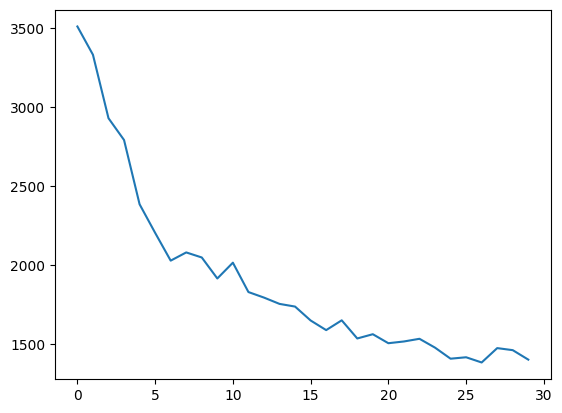

[113673, 113188, 123720, 117007, 116233, 117659, 122207, 116189, 116108, 117828]
regr


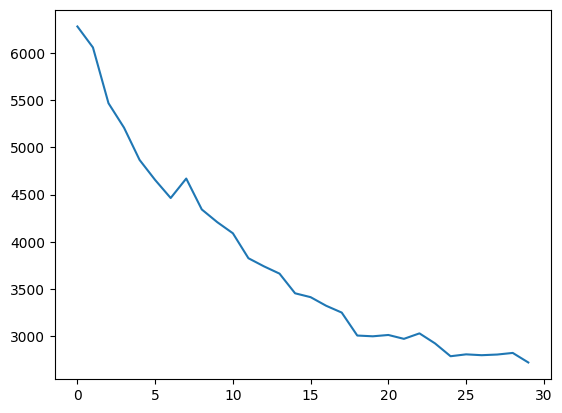

[159146, 159060, 171364, 164088, 163268, 164542, 168752, 162423, 162297, 163896]
regr


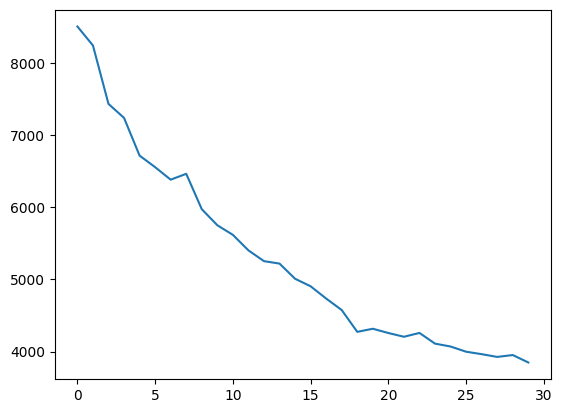

[214921, 215290, 235354, 225217, 223773, 225125, 231514, 222704, 222108, 223872]
regr2


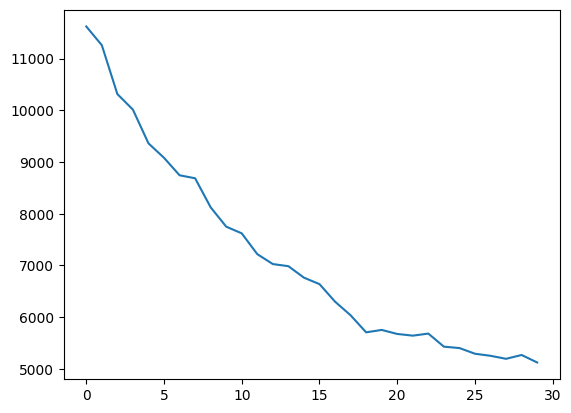

[263942, 264419, 286233, 275102, 273836, 275525, 280658, 271012, 270767, 273134]
regr2


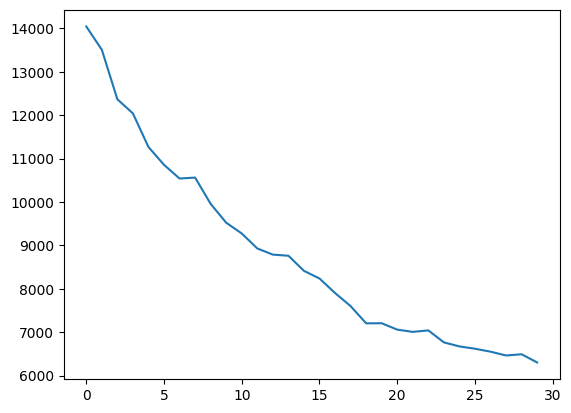

[314020, 313629, 345434, 330068, 326565, 327636, 339237, 325414, 322971, 324827]
regr


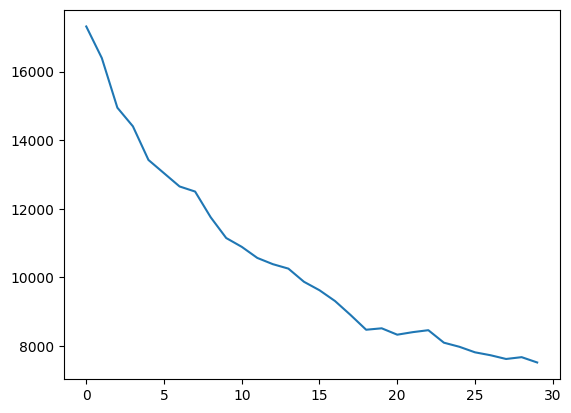

[363219, 363840, 395973, 380345, 377108, 378326, 388951, 375211, 373125, 375086]
regr2


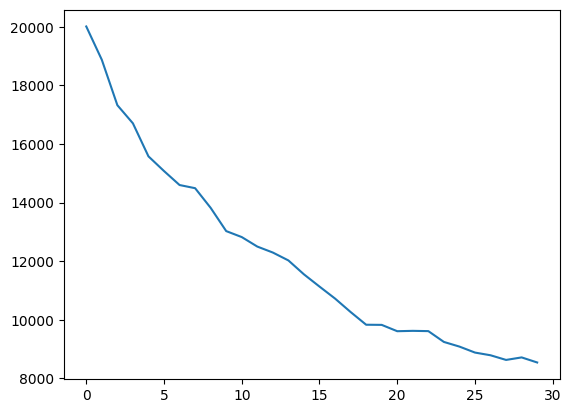

[416266, 417471, 454420, 436334, 433026, 434308, 446799, 431062, 429026, 431086]
regr2


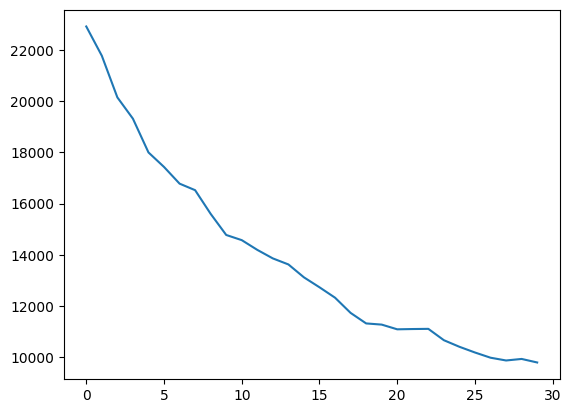

[450803, 452356, 491714, 471991, 468252, 469865, 482959, 465817, 463505, 465992]
regr2


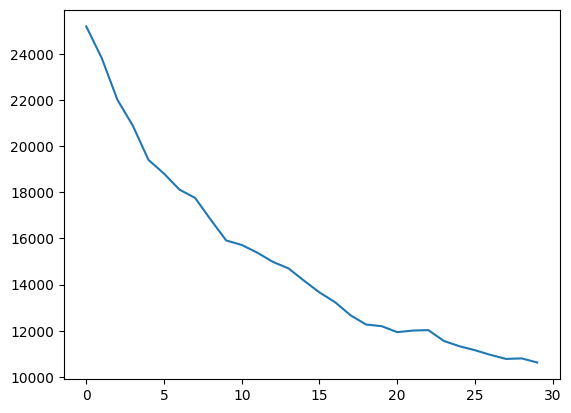

[501660, 503227, 546292, 524177, 520619, 522952, 537038, 517731, 515703, 518912]
regr2


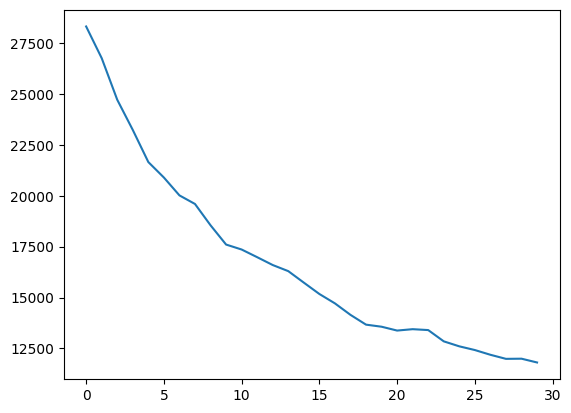

[550059, 551701, 595846, 573386, 570342, 573301, 585578, 566057, 564680, 568556]
regr2


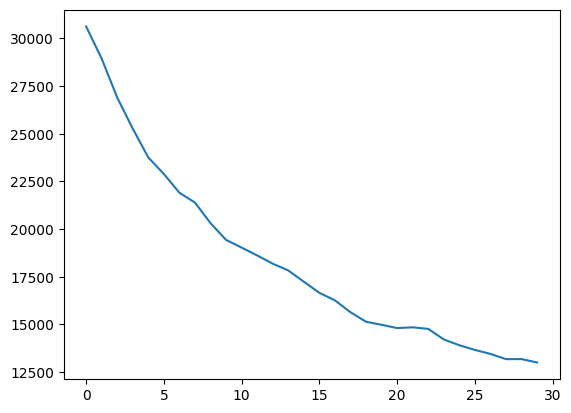

[591801, 593183, 639196, 616246, 613259, 616613, 627792, 608051, 606795, 611205]
regr2


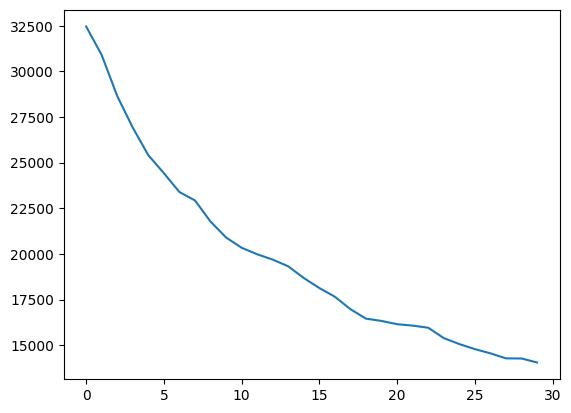

[641596, 644276, 690655, 666965, 664744, 668864, 678348, 658138, 657634, 662921]
regr2


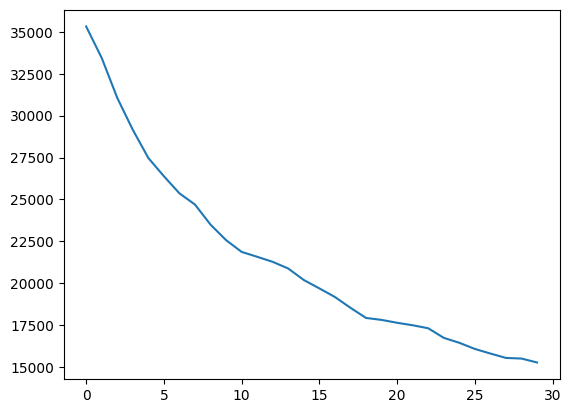

[688153, 690274, 737478, 712410, 709497, 713655, 725322, 703813, 702669, 708035]
regr2


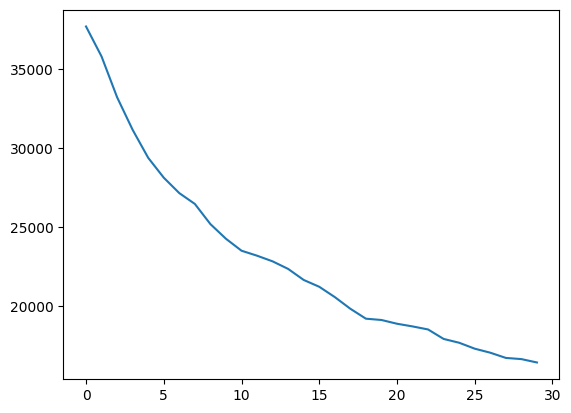

[743789, 746256, 798120, 770903, 767657, 771829, 784484, 761211, 759816, 765275]
regr2


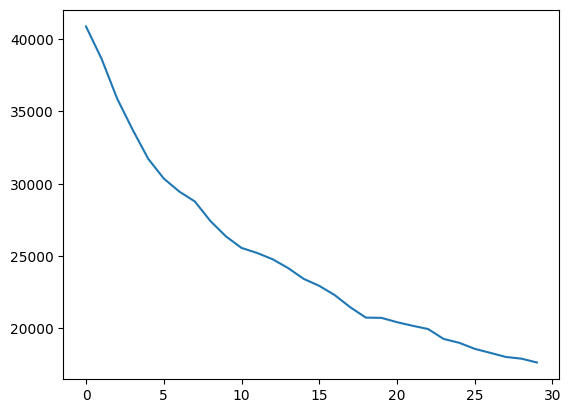

[777601, 780273, 835108, 807004, 803458, 807567, 820259, 796312, 794665, 800007]
regr2


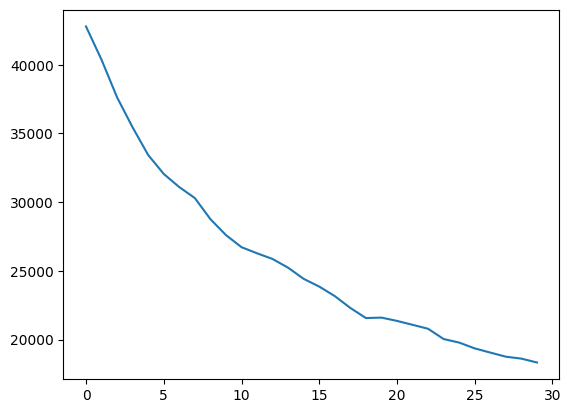

[823518, 826136, 883803, 854714, 851103, 855342, 867627, 842907, 841283, 846769]
regr2


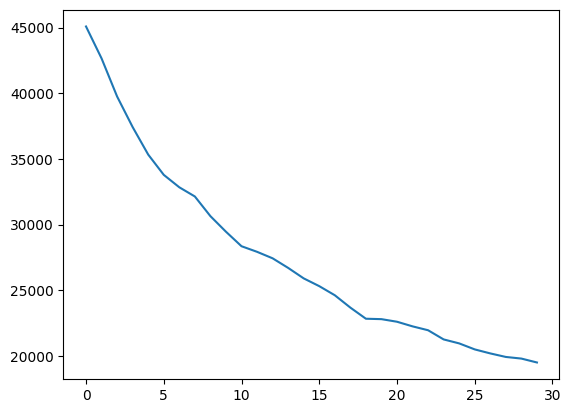

[876021, 879513, 939651, 910013, 906300, 910812, 922421, 897302, 895856, 901769]
regr2


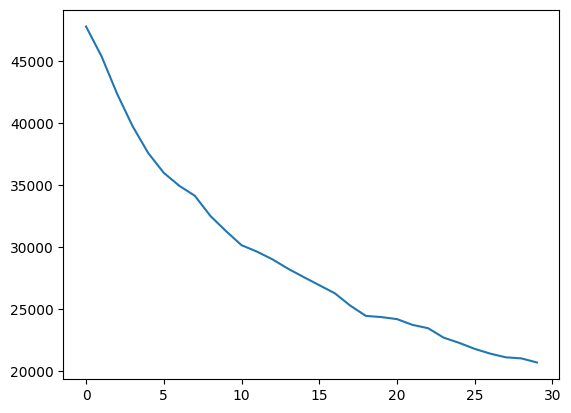

[935757, 939407, 1007583, 974763, 970381, 974948, 988817, 960788, 958635, 964727]
regr2


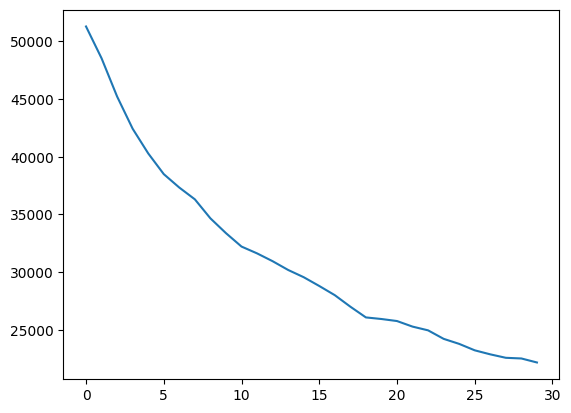

[989471, 992884, 1068440, 1031733, 1026253, 1031009, 1049253, 1017503, 1014454, 1020787]
regr2


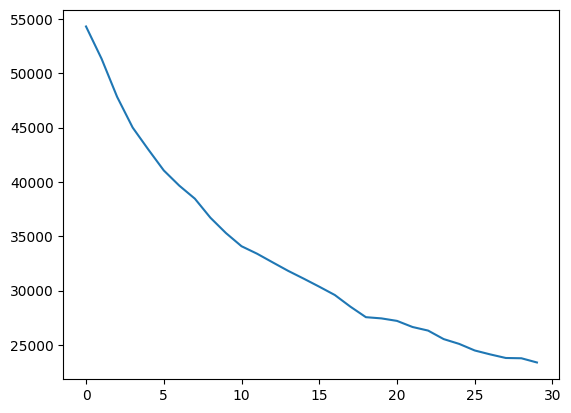

[1036661, 1040826, 1120001, 1081141, 1074677, 1079774, 1099897, 1066416, 1062513, 1069151]
regr2


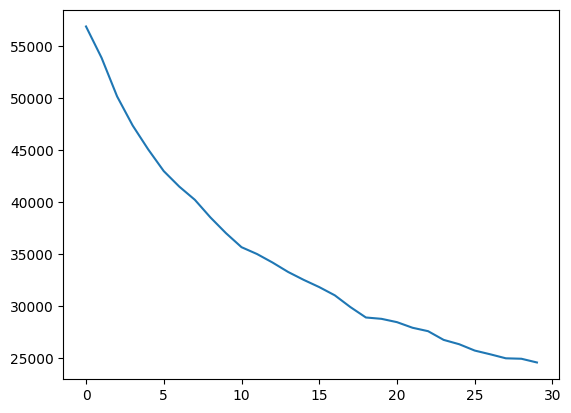

[1091291, 1095787, 1184722, 1142323, 1134026, 1138446, 1162803, 1126042, 1120326, 1126409]
regr2


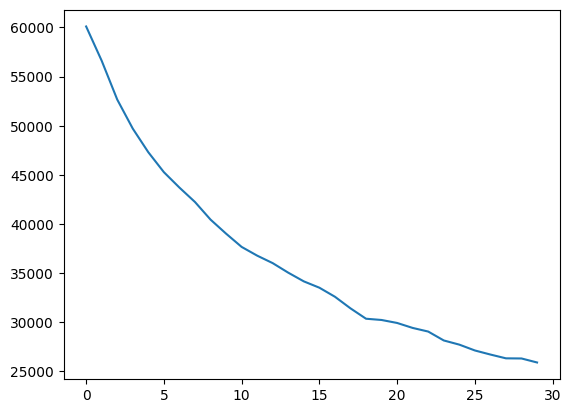

[1143900, 1147870, 1243229, 1197597, 1189106, 1193778, 1220720, 1180957, 1175117, 1181479]
regr2


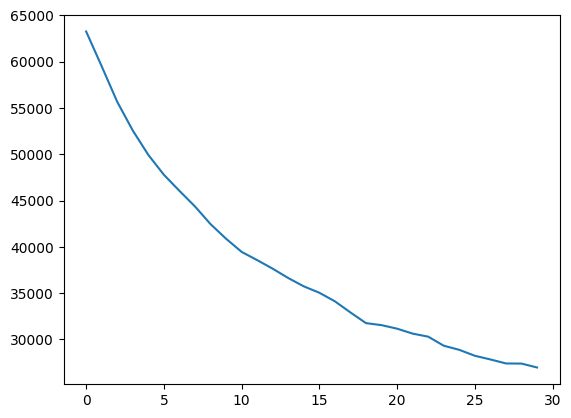

[1196927, 1201017, 1299223, 1252597, 1243582, 1247912, 1276174, 1235440, 1229253, 1235284]
regr2


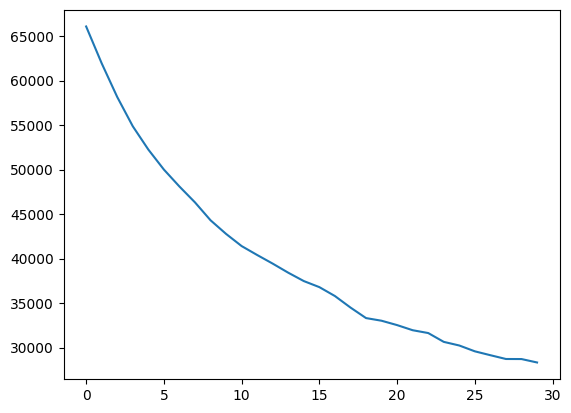

KeyboardInterrupt: 

In [111]:
random.seed(42)
fun_lst = []
fun_name = []
fun_lst.append(regr2(lst_a1,lst_a2,lst_b))
fun_name.append('regr2')
fun_lst.append(regr(lst_oa,lst_ob))
fun_name.append('regr')
for i in np.arange(2.6,3.5,0.5):
    for j in np.arange(6.5,8.5,0.5):
        fun_lst.append(low_up_fun(i,j))
        fun_name.append((i,j))
get_penalty(fun_lst,fun_name)

In [107]:
def regr2(lst_a1, lst_a2, lst_b):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            s3=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,3.1,7.5)
            s2 = s2 + now
            s3 = s3 + now*now
            x1 = s2/s1
            x2 = s3/s1
            med = lst_a1[s1-1]*x1 + lst_a2[s1-1]*x2 + lst_b[s1-1]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [108]:
def regr(lst_a,lst_b):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,3.1,7.5)
            s2 = s2 + now
            med = s2/s1
            med = lst_a[s1-1]*med+lst_b[s1-1]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [49]:
def fun_sigmoid( sc  ):
    def f(last_total_bid,last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*0.5
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1 )
            now=1.0/(1.0+np.exp(  (now-np.log(101))*sc  ))
            s2 = s2 + now
        med = s2/s1
        med = np.exp(   (np.log( 1.0/med - 1.0 )/sc) + np.log(101)   ) - 1
        bid = int((med)/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

In [50]:
def upci(up,offset,ci):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*((offset+min(100.0,up))**ci)
        else:
            s1 = s1 + 1
            now = last_yield
            if now>up:
                now=up
            now = now + offset
            now = now ** ci
            s2 = s2 + now
        med = (s2/s1)**(1.0/ci)
        med = med-offset
        bid = int(med/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

In [51]:
def low_up_fun(low,up):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*np.log(100.0)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1 )
            if now<low:
                now=low
            if now>up:
                now=up
            s2 = s2 + now
        bid = int((np.exp(s2/s1)-1.0)/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

[6310, 6311, 6309, 6292, 6295, 6298, 4349]
[278886, 278057, 279385, 278386, 278795, 279544, 571653]


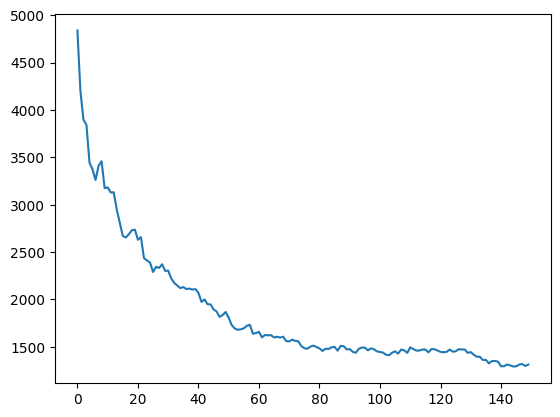

[19661, 19622, 19662, 19683, 19635, 19581, 15080]
[652455, 651966, 652812, 651013, 651957, 655779, 1276590]


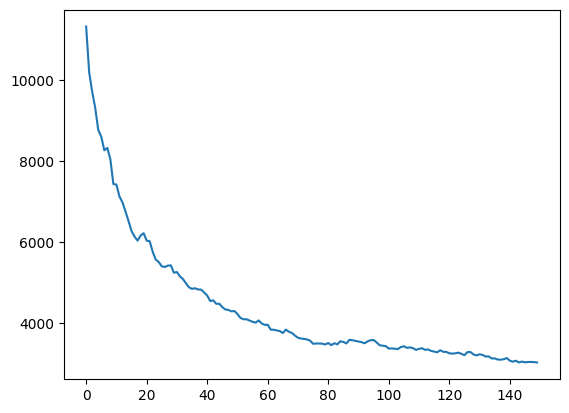

[29411, 29308, 29463, 29453, 29395, 29206, 22017]
[988059, 989508, 988251, 986421, 987353, 996632, 1983585]


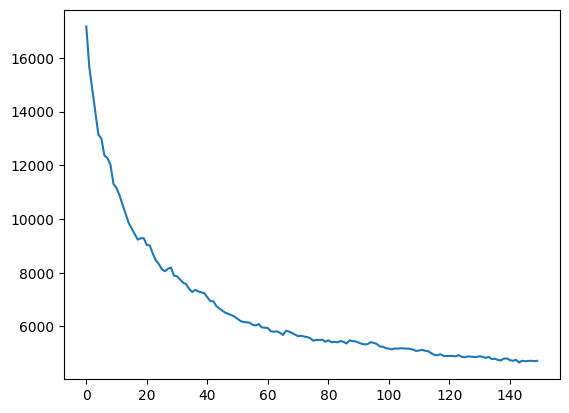

[32427, 32236, 32482, 32476, 32406, 32229, 23696]
[1256177, 1261826, 1256584, 1255192, 1255860, 1272811, 2517824]


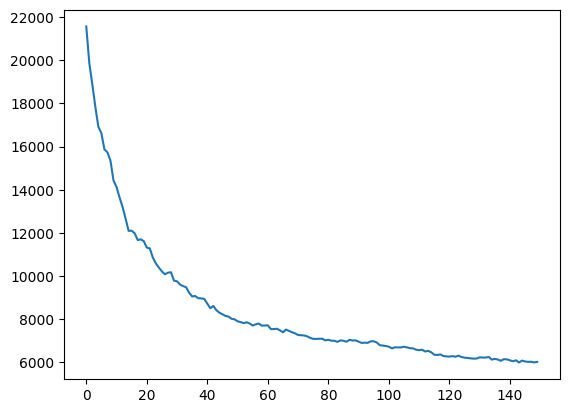

[49993, 49862, 50097, 50084, 49995, 49753, 38162]
[1591491, 1600566, 1592297, 1591838, 1591587, 1612925, 3205142]


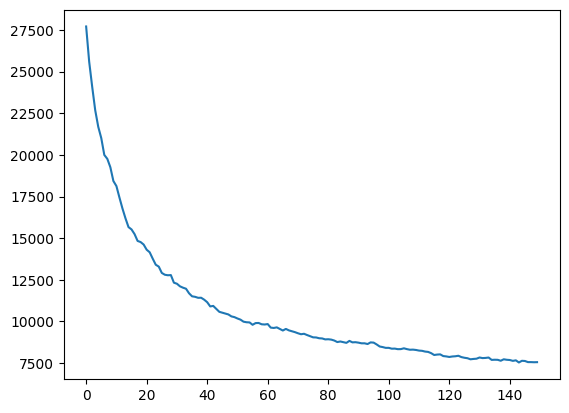

[62819, 62718, 62874, 62920, 62815, 62643, 46373]
[1927467, 1935558, 1928546, 1927408, 1927363, 1949107, 3951947]


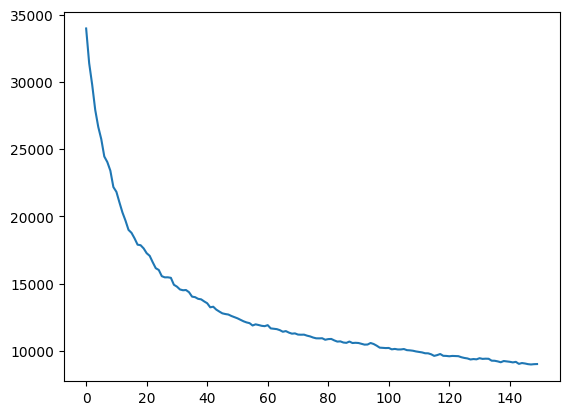

In [320]:
#player_lst = [st2] + [st3] + [st4] + [naive_strategy] * 4
random.seed(42)
player_lst = [low_up_fun(3.15,7.4)] +[low_up_fun(3.0,8.0)]+[low_up_fun(3.2,7.4)]+[low_up_fun(3.1,7.55)] +\
                 [low_up_fun(3.15,7.45)] + [low_up_fun(2.8,8.0)]  + [naive_strategy]
#player_lst = [naive_strategy]*7
Simulation(player_lst)

In [52]:
def st6(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
    else:
        s1 = s1 + 1
        now = np.log( last_yield+1 )
        if now<2.0:
            now=2.0
        #if now>6.2:
        #    now=6.2
        s2 = s2 + now
    bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [53]:
def st4( last_total_bid, last_yield, s1, s2, s3):
    shft = 0
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
        s3=0
    else:
        if last_total_bid > 1.2* (np.exp(s2/s1)):
            if s3<0:
                s3=1
            else:
                s3 = s3+1
        if last_total_bid < 0.8* (np.exp(s2/s1)):
            if s3>0:
                s3=-1
            else:
                s3 = s3-1
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
    if s3>3:
        shft = s3-3
    if s3<-3:
        shft = s3+3
    bid = int((np.exp(s2/s1))/7 - 0.5 - shft)
    return (bid,s1,s2,s3)

In [54]:
def st3(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
    else:
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
    bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [55]:
def st2(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        bid = 14
        s1=0
        s2=0.0
    else:
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
        bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [56]:
from random import randint
def st5(last_total_bid, last_yield, s1, s2, s3):
    bid=14
    if last_yield == -1:
        s1=-1
        s2=-1
        s3=-1
    elif s1==-1:
        s1=last_yield
    elif s2==-1:
        s2=last_yield
    elif s3==-1:
        s3=last_yield
    else:
        lst = [s1,s2,s3,last_yield]
        sorted_lst = sorted(lst)
        bid = int((s2)/7+0.5)
        x = randint(1,4)
        if x==1:
            s1=last_yield
        if x==2:
            s2=last_yield
        if x==3:
            s3=last_yield
        
        
    return (bid,s1,s2,s3)

In [57]:
def naive_strategy( last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        bid = 14
    elif last_total_bid<=last_yield:
        bid = s1+1
    else:
        bid = s1-1
    if bid<0:
        bid = 0
    s1 = bid
    return (bid,s1,s2,s3)

In [58]:
def st1( last_total_bid, last_yield, s1, s2, s3):
    bid = 14
    return (bid,s1,s2,s3)

In [69]:
sample_median([11,11,10,9,8])

74.0

In [68]:
for i1 in range(8,9):
    for i2 in range(i1,11):
        for i3 in range(i2,12):
            for i4 in range(i3,13):
                for i5 in range(i4,14):
                    v = get_median_by_ywlst([i5,i4,i3,i2,i1])
                    if v==74:
                        print([i5,i4,i3,i2,i1])

[10, 8, 8, 8, 8]
[13, 12, 9, 9, 8]
[13, 10, 10, 9, 8]
[11, 11, 10, 9, 8]
